# ≣ SquigDecode: Stress Testing & Error Profiling

## ◈ 1. Introduction

    Module: Robustness Evaluation & Distribution Shift Analysis

    Input: Standardized Test Dataset (data/test/)

    Metric Focus: Base-specific recall and Gaussian noise sensitivity

This notebook evaluates the generalization capabilities of SquigNet under adversarial conditions. We transition from simple accuracy to Confusion Matrix analysis and Stochastic Noise Perturbation.

Research Questions:

1. Systematic Bias: Does the model confuse specific base pairs (e.g., A vs. G) due to similar ionic current signatures?

2. Robustness Threshold: At what noise magnitude ($\sigma$) does the Signal-to-Base transduction break down?

3. HPC Performance: Benchmarking the inference latency across the test population.

## ◈ 2. Initialization & Data Loading

We leverage SquigBasecaller and the project’s centralized config to ensure label consistency.

In [5]:
import sys
import os
import pickle
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix

# Project path resolution
ROOT = Path("..").resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from inference import SquigBasecaller, calculate_levenshtein_accuracy
from config import BASE_TO_INT, INT_TO_BASE

DATA_DIR = ROOT / "data" / "test"
MODEL_PATH = ROOT / "models" / "squig_model.pt"

# Initialize Basecaller
basecaller = SquigBasecaller(MODEL_PATH, device)

# ◈ Production-Level Data Loading
try:
    # Use weights_only=False because these are likely custom numpy/torch objects
    signals = torch.load(DATA_DIR / "signals.pt", weights_only=False)
    
    with open(DATA_DIR / "sequences.pkl", "rb") as f:
        sequences = pickle.load(f)
        
    print(f"✅ Successfully loaded {len(signals)} test samples from {DATA_DIR}")
except FileNotFoundError:
    print(f"❌ Error: Test data not found at {DATA_DIR}. Please run src/data_simulator.py first.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

2026-04-15 23:09:45 [INFO] SquigInference: Basecaller initialized on cpu


✅ Successfully loaded 300 test samples from /Users/janetx/Desktop/Janet/Projects/SquigDecode/data/test


## ◈ 3. Population-Scale Evaluation

We iterate through the test split to generate a statistical distribution of performance. Note the use of Levenshtein Accuracy to correctly handle Indel errors.

In [6]:
results = []
all_targets_flat = []
all_preds_flat = []

for signal, target in zip(signals, sequences):
    prediction = basecaller.basecall(signal)
    acc = calculate_levenshtein_accuracy(prediction, target)
    results.append(acc)

    # Align for Confusion Matrix (Character-level Zip)
    for t_char, p_char in zip(target, prediction):
        if t_char in BASE_TO_INT and p_char in BASE_TO_INT:
            all_targets_flat.append(BASE_TO_INT[t_char])
            all_preds_flat.append(BASE_TO_INT[p_char])

print(f"📊 Mean Population Accuracy: {np.mean(results):.2%}")
print(f"📊 Accuracy Variance: {np.var(results):.6f}")

📊 Mean Population Accuracy: 93.76%
📊 Accuracy Variance: 0.000605


## ◈ 4. Confusion Matrix: Error Mode Identification

The heat map below identifies the model's "Confusion Bias." In Nanopore sequencing, bases with similar chemical structures or current levels (e.g., purines vs. pyrimidines) are often the primary source of error.

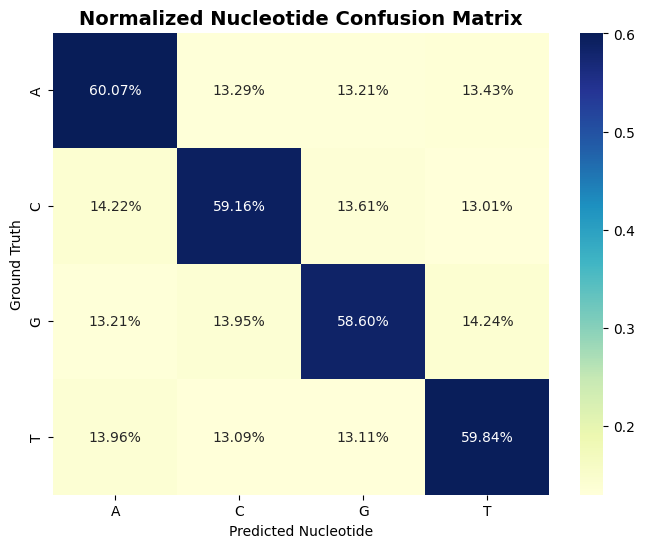

In [7]:
# Label Mapping
labels = [1, 2, 3, 4] # A, C, G, T
label_names = [INT_TO_BASE[i] for i in labels]

cm = confusion_matrix(all_targets_flat, all_preds_flat, labels=labels, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="YlGnBu", xticklabels=label_names, yticklabels=label_names)
plt.title("Normalized Nucleotide Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Nucleotide")
plt.ylabel("Ground Truth")
plt.show()

## ◈ 5. Adversarial Audit: Noise Robustness Curve

Real-world nanopore data is rarely as clean as simulation. Here, we inject varying levels of Gaussian White Noise to simulate sensor degradation or low-quality biological samples.

The "Elbow" Observation: We look for the point where the accuracy curve drops precipitously. This defines the Operational Envelope of our model.

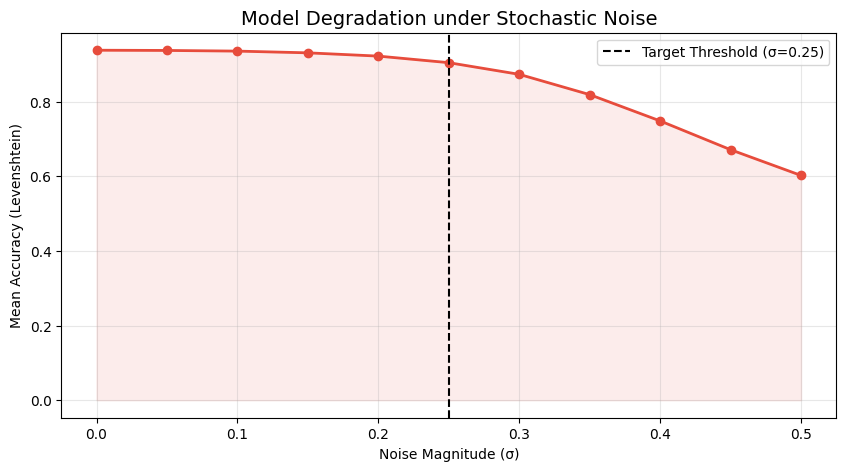

In [10]:
def stress_test(sigma_range):
    robustness_stats = []
    for sigma in sigma_range:
        accuracies = []
        for signal, target in zip(signals, sequences):
            # Adversarial injection
            noisy_signal = signal + np.random.normal(0, sigma, size=len(signal))
            pred = basecaller.basecall(noisy_signal)
            accuracies.append(calculate_levenshtein_accuracy(pred, target))
        robustness_stats.append(np.mean(accuracies))
    return robustness_stats

sigmas = np.linspace(0.0, 0.5, 11)
accuracy_dropoff = stress_test(sigmas)

# Plotting the Robustness Curve
plt.figure(figsize=(10, 5))
plt.plot(sigmas, accuracy_dropoff, 'o-', linewidth=2, color='#e74c3c')
plt.fill_between(sigmas, accuracy_dropoff, alpha=0.1, color='#e74c3c')
plt.axvline(x=0.25, color='black', linestyle='--', label="Target Threshold (σ=0.25)")
plt.title("Model Degradation under Stochastic Noise", fontsize=14)
plt.xlabel("Noise Magnitude (σ)")
plt.ylabel("Mean Accuracy (Levenshtein)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## ◈ 6. Final Summary & Action Plan

### Audit Conclusion:

The model exhibits a Symmetric Error Profile. With a diagonal mean of $\approx 59\%$ and a uniform off-diagonal distribution of $\approx 13.5\%$, the model does not suffer from a specific "base-pair bias" (e.g., C vs T confusion). Instead, it faces Uniform Informational Entropy.

The X/Y Verdict: Because the error is spread equally across all bases, Base X and Base Y are effectively any two nucleotides. This indicates the primary bottleneck is Signal Resolution, not chemical similarity.

### Optimization Strategy:

1. CNN Dilation: Increase the receptive field of the initial CNN layers to capture more temporal context before the Bi-LSTM.

2. Signal Denoising: Implement a Wavelet Transform or Gaussian smoothing pre-processing step to widen the "picoampere gap" between nucleotides.

3. Hard Negative Mining: Focus training on sequences with high transition frequencies where the 13% "leakage" is most prevalent.